In [67]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import h5py
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import torch
import matplotlib.pylab as plt
from synthetic_observations import Observations
from gaussian_synthetic_observations import Gaussian_Observations
from transformer import *
from spectrum_lsf import Score_Likelihood
from score_models import ScoreModel
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from template import Template
from sbart_rv_finder import RV_Retrieval
from mala import MALA
from matplotlib import gridspec



In [68]:
import h5py
import os
import re

folder = "../gibbs_sampling/results"   # your results folder
phoenix_data = {}        # keyed by (snr, nspec)
files = ['order_04_i0_snr10_nspec10.h5','order_29_i0_snr10_nspec10.h5','full_snr_small_mod_i0_snr10_nspec10.h5',
'order_04_i6_snr10_nspec10.h5','order_29_i6_snr10_nspec10.h5','full_snr_small_mod_i6_snr10_nspec10.h5']
ord = 0
for filename in os.listdir(folder):
    if filename in files:
        filepath = os.path.join(folder, filename)
        
        with h5py.File(filepath, "r") as f:
            # Read observational params
            i = f['Order']['Observational Parameters'].attrs['i']
            snr = f['Order']['Observational Parameters'].attrs['snr']
            nspec = f['Order']['Observational Parameters'].attrs['nspec']
            print(filename,ord)
            if ord ==2 or ord==5:
                order = 29
            elif ord==0 or ord==3:
                order =4
            else:
                order = 20

            # Spectrum (optional, if you need it)
            spectrum_group = f['Order']['Observational Parameters']['Spectrum']
            spectrum_analysis = {name: dset[:] for name, dset in spectrum_group.items()}

            # RV Samples
            rv_group = f['Order']['Observational Parameters']['RV Samples']
            rv_analysis = {
                seed: {subname: subdset[:] for subname, subdset in seed_group.items()}
                for seed, seed_group in rv_group.items()
            }

            # Store under (snr, nspec, step)
            phoenix_data[(order,i, snr, nspec)] = {
                "spectrum": spectrum_analysis,
                "rv": rv_analysis,
            }

            wgrid = f['Order']['wgrid'][:] 
            non_ones = f['Order']['non_ones'][:] 
            inst_wgrid = f['Order']['inst_wgrid'][:]
            ord+=1


order_04_i6_snr10_nspec10.h5 0
full_snr_small_mod_i6_snr10_nspec10.h5 1
order_29_i0_snr10_nspec10.h5 2
order_04_i0_snr10_nspec10.h5 3
full_snr_small_mod_i0_snr10_nspec10.h5 4
order_29_i6_snr10_nspec10.h5 5


In [69]:
import h5py
import os
import re

folder = "../proxima/results"   # your results folder
proxima_data = {}        # keyed by (snr, nspec)
files = ['order_04_i0_snr10_nspec10.h5','order_29_i0_snr10_nspec10.h5','full_snr_small_mod_i0_snr10_nspec10.h5']
ord = 0
for filename in os.listdir(folder):
    if filename in files:
        filepath = os.path.join(folder, filename)
        with h5py.File(filepath, "r") as f:
            # Read observational params
            i = f['Order']['Observational Parameters'].attrs['i']
            snr = f['Order']['Observational Parameters'].attrs['snr']
            nspec = f['Order']['Observational Parameters'].attrs['nspec']
            print(filename,ord)
            if ord ==0:
                order = 29
                wgrid29 = f['Order']['wgrid'][:] 
            elif ord==1:
                order =4
                wgrid4 = f['Order']['wgrid'][:] 
            else:
                order = 20
                wgrid20 = f['Order']['wgrid'][:] 
            

            # Spectrum (optional, if you need it)
            spectrum_group = f['Order']['Observational Parameters']['Spectrum']
            spectrum_analysis = {name: dset[:] for name, dset in spectrum_group.items()}

            # RV Samples
            rv_group = f['Order']['Observational Parameters']['RV Samples']
            rv_analysis = {
                seed: {subname: subdset[:] for subname, subdset in seed_group.items()}
                for seed, seed_group in rv_group.items()
            }

            # Store under (snr, nspec, step)
            proxima_data[(order,i, snr, nspec)] = {
                "spectrum": spectrum_analysis,
                "rv": rv_analysis,
            }

            wgrid = f['Order']['wgrid'][:] 
            non_ones = f['Order']['non_ones'][:] 
            inst_wgrid = f['Order']['inst_wgrid'][:]
            ord+=1


order_29_i0_snr10_nspec10.h5 0
order_04_i0_snr10_nspec10.h5 1
full_snr_small_mod_i0_snr10_nspec10.h5 2


In [70]:
start = int(0.1*wgrid.shape[-1])
end = int(0.90*wgrid.shape[-1])

s1 = int(0.1*inst_wgrid.shape[-1])
e1 = int(0.9*inst_wgrid.shape[-1])

start = np.searchsorted(wgrid, inst_wgrid[s1])
end = np.searchsorted(wgrid, inst_wgrid[e1])

In [78]:
wgrid4

array([1006.95687171, 1006.95854997, 1006.96022823, ..., 1038.9089663 ,
       1038.91069781, 1038.91242933])

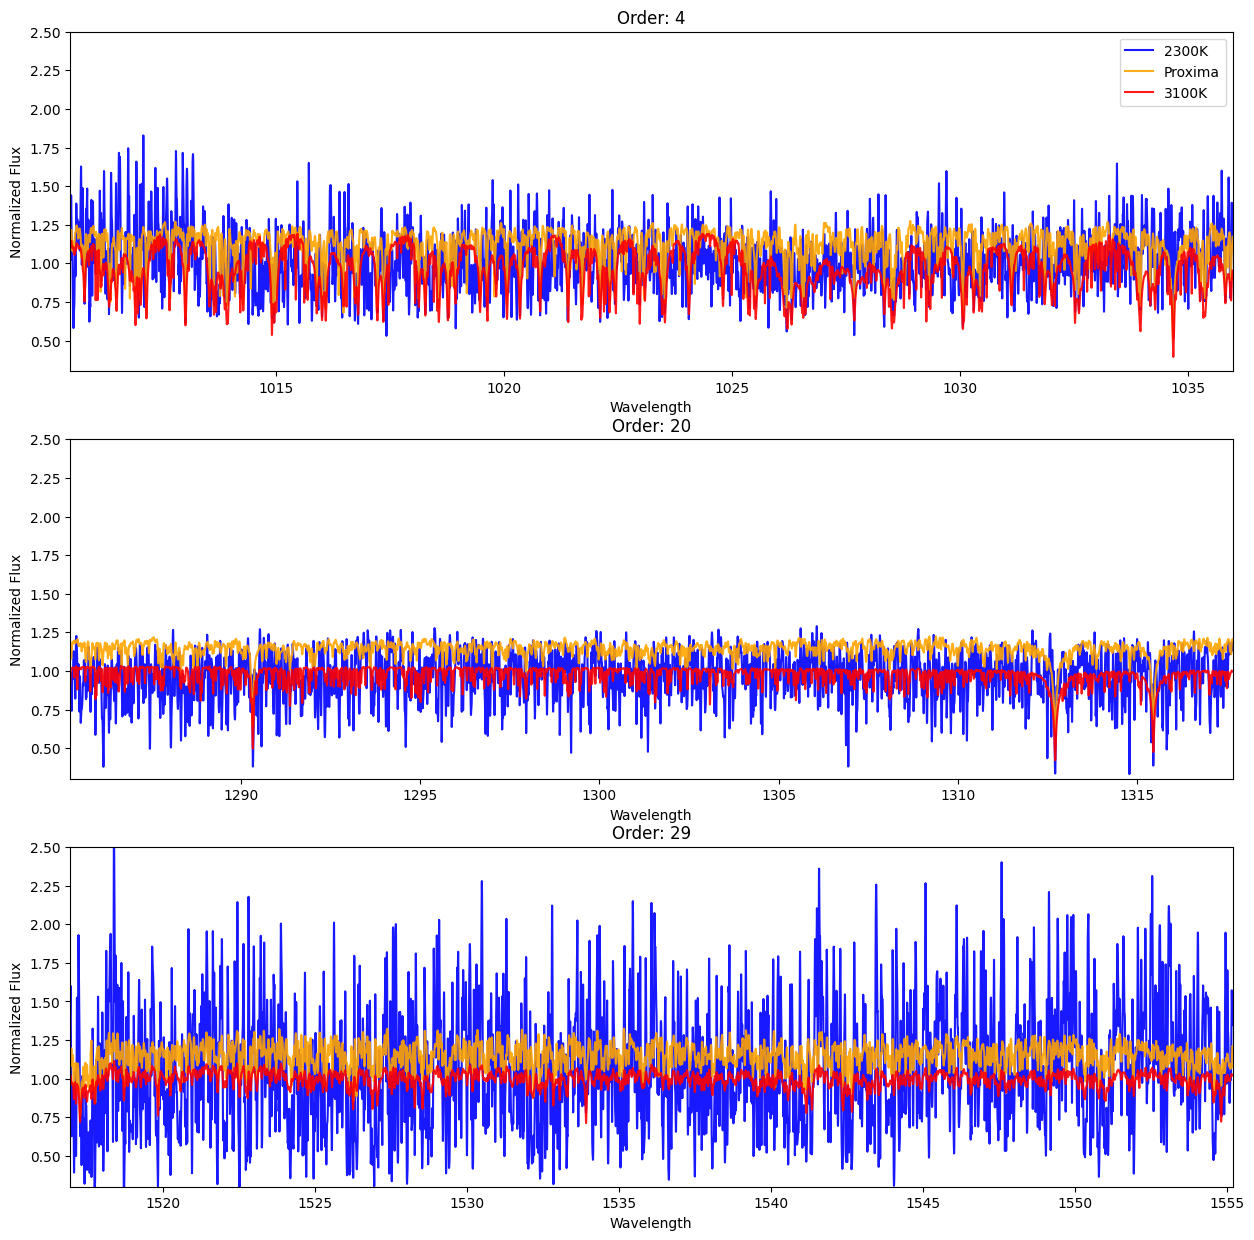

In [87]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig, axs = plt.subplots(3,1,figsize=(15,15))
for i,o in enumerate([4,20,29]):
    spectrum_analysis = phoenix_data[(o, 0, 10,nspec)]['spectrum']

    wavelength = wgrid[start:end]
    true_spec_0 = spectrum_analysis['true_spectrum'][0,0][start:end]

    spectrum_analysis = phoenix_data[(o, 6, 10,nspec)]['spectrum']

    wavelength = wgrid[start:end]
    true_spec_6 = spectrum_analysis['true_spectrum'][0,0][start:end]

    spectrum_analysis = proxima_data[(o, 0, 10,nspec)]['spectrum']

    wavelength = wgrid[start:end]
    true_spec_prox = spectrum_analysis['true_spectrum'][0,0][start:end]
    if o==4:
        wavelength = wgrid4[start:end]
    elif o==29:
        wavelength = wgrid29[start:end]
    else:
        wavelength = wgrid20[start:end]

    axs[i].plot(wavelength,true_spec_6,label="2300K",c='b',alpha=0.9) 
    axs[i].plot(wavelength,true_spec_prox,label="Proxima",c='orange',alpha=0.9)   
    axs[i].plot(wavelength,true_spec_0,label="3100K",c='r',alpha=0.9)
    axs[i].set_ylim(0.3,2.5)
    axs[i].set_xlim(wavelength[0],wavelength[-1])
    axs[i].set_xlabel("Wavelength")
    axs[i].set_ylabel("Normalized Flux")
    axs[i].set_title("Order: "+str(o))

axs[0].legend()
